<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Isaac Patricio Torrejón
- Nombre de alumno 2: Marcelo Iván Palma


### **Link de repositorio de GitHub:** [epositorio](https://github.com/Mpalma325/Laboratorio-de-Programacion-Cientifica-para-Ciencia-de-Datos)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import gdown
import zipfile
#Carga de Datos (Si se trabaja en colab activar esta celda)
colab=True
if colab:
  file_id = "1YYbexi3OY2mZVXpopHXHwzK6Ii50U5vP"
  url = f"https://drive.google.com/uc?id={file_id}"

  output = "diabetes_data.csv"
  gdown.download(url, output, quiet=False)



Downloading...
From: https://drive.google.com/uc?id=1YYbexi3OY2mZVXpopHXHwzK6Ii50U5vP
To: /content/diabetes_data.csv
100%|██████████| 5.29M/5.29M [00:00<00:00, 28.7MB/s]


In [2]:
import numpy as np
import pandas as pd


df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,70692.0,8.584055,2.852153,1.0,7.0,9.0,11.0,13.0
Sex,70692.0,0.456997,0.498151,0.0,0.0,0.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0
Veggies,70692.0,0.788774,0.408181,0.0,1.0,1.0,1.0,1.0


La mayoría de las variables son binarias. Por lo mismo, se puede considerar que esas están bien estandarizadas.

Por otro lado, es necesario estandarizar, "Age", "BMI","MentHlth", "PhysHlth", "GenHlth". Que son las únicas variables no binarias del dataset.



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

X = df.drop('Diabetes', axis=1)
y = df['Diabetes']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=19, stratify=y
)
cols_to_scale = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'GenHlth']

preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), cols_to_scale)],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    device='cuda',
    eval_metric='logloss',
    random_state=19)

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', xgb),
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

         0.0      0.776     0.710     0.742     11782
         1.0      0.733     0.795     0.763     11782

    accuracy                          0.753     23564
   macro avg      0.755     0.753     0.752     23564
weighted avg      0.755     0.753     0.752     23564



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [01:25:48] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Luego de los resultados obtenidos por el modelo. Se observa que tanto para la clase 1 como para la clase 0, los resultados tienen un buen balance de precision-recall. Con la clase 0 destacando en precision y la clase 1 destacando en recall.
Esto lleva a un accuracy global de 0.753. Es decir, el 75.3% de los casos son bien catalogados. Esto se puede considerar un buen predictor de diabetes, sin embargo es demasiado mejorable. Ya que si se implementará en la realidad, un 25% de las personas no se les estaría catalogando de manera correcta en un tema tan delicado como la diabetes.

Las métricas utilizadas buscan medir que tanto se está prediciendo de manera correcta, penalizando distintos errores (Precision aborda los casos abordados de manera incorrecta mientras que Recall los casos no abordados como 1)

Esta forma de visualizar las métricas no permite saber la importancia de ninguna feature, y deja al modelo actuando bajo un sistema de "Caja Negra", donde solo se sabe el output, pero no que es lo que está realizando detrás, por lo que las features podrían ser redundantes, ruidosas o mal utilizadas por el modelo. (Como un caso en el que tome la edad como un factor inversamente proporcional a la probabilidad de diabetes, lo cual es incorrecto).





## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

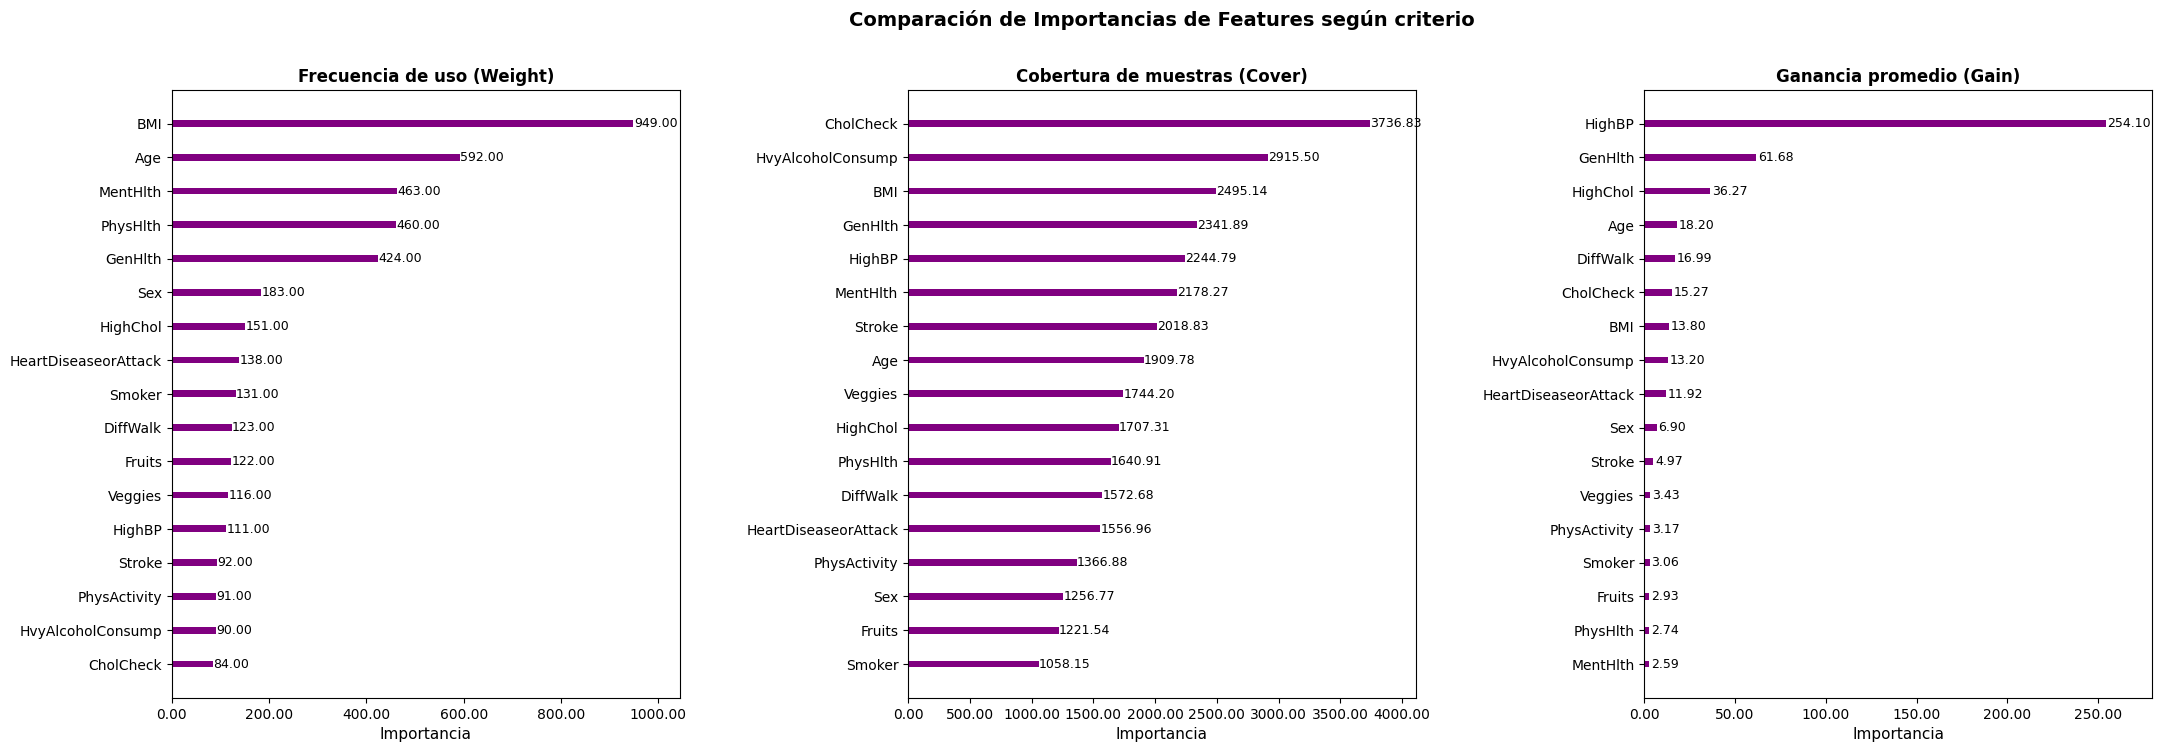

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import plot_importance
from matplotlib.ticker import FormatStrFormatter

booster = pipe.named_steps['clf'].get_booster()
feature_names = list(pipe.named_steps['prep'].get_feature_names_out())
booster.feature_names = feature_names
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
importance_types = ['weight', 'cover', 'gain']
titles = ['Frecuencia de uso (Weight)', 'Cobertura de muestras (Cover)', 'Ganancia promedio (Gain)']

for ax, imp_type, title in zip(axes, importance_types, titles):
    bars = plot_importance(
        booster,
        importance_type=imp_type,
        ax=ax,
        xlabel='Importancia',
        title=None,
        grid=False,
        color='purple',
    )


    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_xlabel('Importancia', fontsize=11)
    ax.set_ylabel('')

    for text in ax.texts:
        try:
            val = float(text.get_text())
            text.set_text(f"{val:.2f}")
            text.set_fontsize(9)
        except ValueError:
            pass

fig.suptitle('Comparación de Importancias de Features según criterio', fontsize=16, fontweight='bold')


fig.suptitle('Comparación de Importancias de Features según criterio',
             fontsize=14, fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.12, wspace=0.45)

plt.show()


3.2 Los resultados no son directamente compatibles. Es esperable que variables con una buena importancia en el modelo destaquen en los 3 criterios. Sin embargo, tal como se observa, en ninguna el orden es el mismo ni se parece. Dado que cada criterio mide un aspecto distinto de importancia, por ejemplo BMI es la que más pesa. Pero HighBP es por lejos la que mas Gain genera.

3.3 Las importancias obtenidas no alcanzan a ser suficientes para interpretar el modelo de arboles, esto dado que, no se saben las importancias individuales ni como afectan directamente a la decisión. Lo obtenido anteriormente es una visión muy agregada de las importancias que tienen las features en cuanto a la construcción del arbol y el aprendizaje de este. Pero no se sabe ni como ni cuanto ni en que dirección afecta cada variable al modelo.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

,feature,drop_mean,drop_std
0,GenHlth,0.050808,0.002061
1,BMI,0.029993,0.001421
2,Age,0.024687,0.001697
3,HighBP,0.014374,0.000855
4,HighChol,0.009488,0.000821
5,HvyAlcoholConsump,0.004101,0.000641
6,CholCheck,0.003715,0.000567
7,Sex,0.002594,0.000776
8,HeartDiseaseorAttack,0.002082,0.000486
9,DiffWalk,0.001535,0.000618


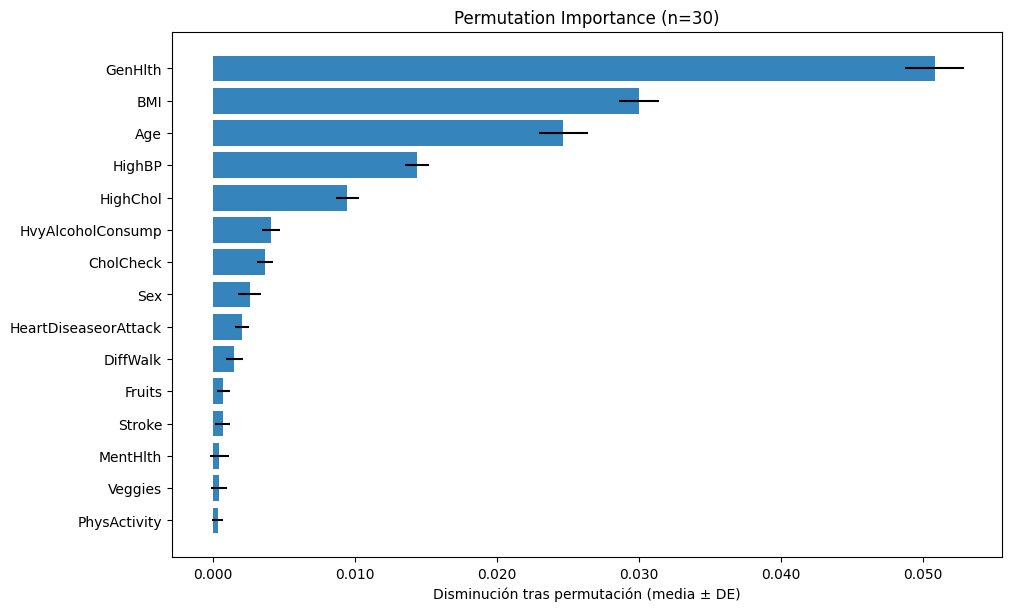

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import accuracy_score

np.random.seed(19)

_prep = pipe.named_steps["prep"]
_clf  = pipe.named_steps["clf"]
feats = list(_prep.get_feature_names_out())
Xt = pd.DataFrame(_prep.transform(X_test), columns=feats, index=X_test.index)
base_acc = accuracy_score(y_test, _clf.predict(Xt))

def permutation_importance_df(estimator, X, y, n_repeats=30):
    drops = np.empty((n_repeats, X.shape[1]), dtype=float)
    Xp = X.copy()

    for r in range(n_repeats):
        for j, f in enumerate(X.columns):
            col = Xp[f].values.copy()
            Xp[f].values[:] = np.random.permutation(col)
            drops[r, j] = base_acc - accuracy_score(y, estimator.predict(Xp))
            Xp[f].values[:] = col

    mean_drop = drops.mean(axis=0)
    std_drop = drops.std(axis=0, ddof=1)
    output = (pd.DataFrame({"feature": X.columns, "drop_mean": mean_drop, "drop_std": std_drop})
             .sort_values("drop_mean", ascending=False)
             .reset_index(drop=True))
    return output

imp_df = permutation_importance_df(_clf, Xt, y_test, n_repeats=30)

display(imp_df.head(15))

plot_df = imp_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.barh(plot_df["feature"], plot_df["drop_mean"], xerr=plot_df["drop_std"], alpha=0.9)
ax.set_xlabel("Disminución tras permutación (media ± DE)")
ax.set_title("Permutation Importance (n=30)")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.show()


4.2 La Desviación Estandar sirve para saber que tan robusta es la importancia que tiene cada variable en el modelo general. Una desviación estandar alta relativa a la feature indica que a veces para el modelo es muy importante, y a veces su importancia es muy baja.

En este caso casi todas las desviaciones estandar son muy bajas. Sin embargo, se observan features como "Veggies", que tienen una desviación esandar superior a la media, por lo que son variables que no tienen ninguna importancia a nivel general.


4.4 Esta importancia evalúa la relevancia de cada variable midiendo cuánto disminuye el desempeño del modelo (accuracy) cuando los valores de esa variable se permutan aleatoriamente.

Si al permutar una variable el rendimiento cae significativamente, significa que el modelo dependía fuertemente de ella para realizar predicciones.


Las 5 features más importantes según este enfoque son  La percepción general de salud (GenHlth), el índice de masa corporal (BMI), la edad (Age), la hipertensión (HighBP) y el colesterol elevado (HighChol).

Esto hace mucho sentido, ya que es algo conocido que tanto el peso como la edad son factores para generar diabetes, mientras que hipertensión y colesterol elevadas estan fuertemente asociadas a la Diabetes.

Permutation importance es una medida más directa del impacto real de cada variable en la predicción, evaluando el efecto sobre la métrica del modelo, no sobre la estructura interna de los árboles.

Además, el realizar 30 iteraciones, permite resultados más robustos y por tanto , las conclusiones son más interpretables y estables.

Como ventaja, esta medida tiene que es directamente interpretable, tal como se menciono cuantifica cuánto empeora el desempeño real del modelo al romper la relación de una feature con la variable objetivo.

Otra ventaja, es que comparado a la medida de importancias anterior, puede aplicarse a cualquier tipo de modelo ya que solo requiere medir el cambio en la métrica al permutar una variable.

Además, detecta features inútiles, ya que si al permutar una variable no cambia el desempeño, se puede concluir como poco informativa o redundante.



Como desventaja tiene su alto costo computacional, dado que es necesario hacer una cantidad de repeticiones x features, lo que puede ser muy lento en modelos o datasets grandes.

La medida puede no ser informativa si existen variables correlacionadas, al permutar una de ellas la otra puede seguir aportando información, subestimando fuertemente su importancia.

En relación a esto mismo, puede subestimar interaccione, ya que si una variable solo es relevante cuando interactúa con otra, permutarla no mide directamente su importancia.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [7]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

/tmp/ipython-input-1592910479.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, Xt, plot_type="dot", show=True)


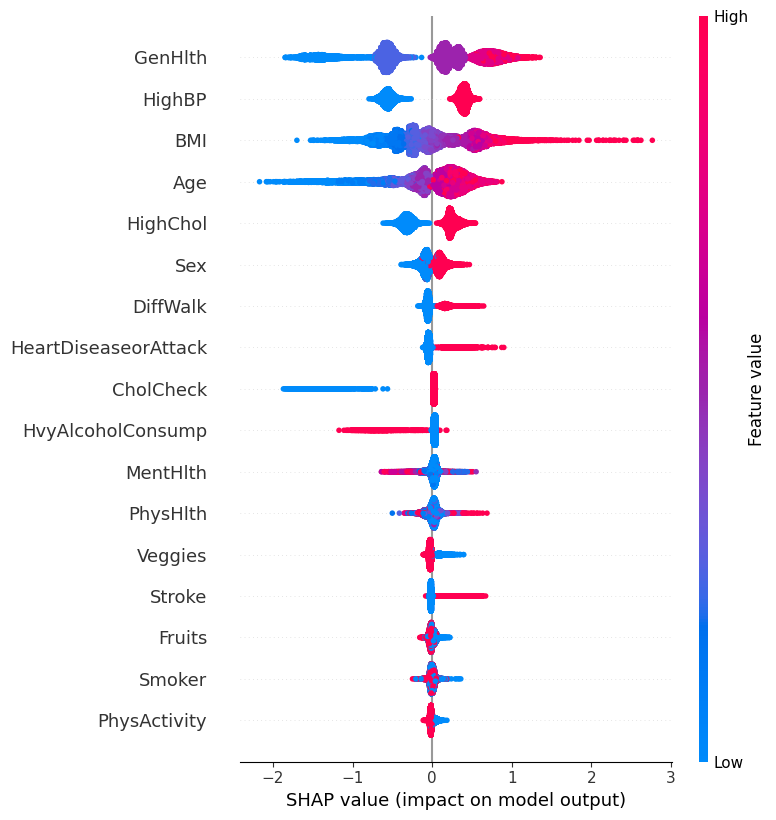

In [8]:
import shap

explainer = shap.TreeExplainer(_clf)
shap_values = explainer.shap_values(Xt)

shap.summary_plot(shap_values, Xt, plot_type="dot", show=True)

5.1.2 En el gráfico, cada punto corresponde a un paciente, y su posición en el eje X muestra el valor SHAP de esa variable para esa persona.

Cada número representa cuánto y en qué dirección una variable contribuye a la predicción individual del modelo para cada paciente.

Un  SHAP value de alta magnitud indica que esa variable tiene un gran impacto en la salida del modelo, los valores más cercanos a 0 muestran que no tiene mayor incidencia en el modelo para esa instancia.



5.1.3 Un valor SHAP positivo implica que la feature empuja la predicción hacia la clase positiva, mientras que uno negativo implica que la feature empuja la predicción hacia la clase negativa (menor probabilidad de diabetes).

En este caso, por ejemplo se observa como a mayor BMI el SHAP value es más alto, dando así que a mayor indice de masa corporal, más factible es que el modelo considere que el paciente tiene diabetes.

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

Paciente 1


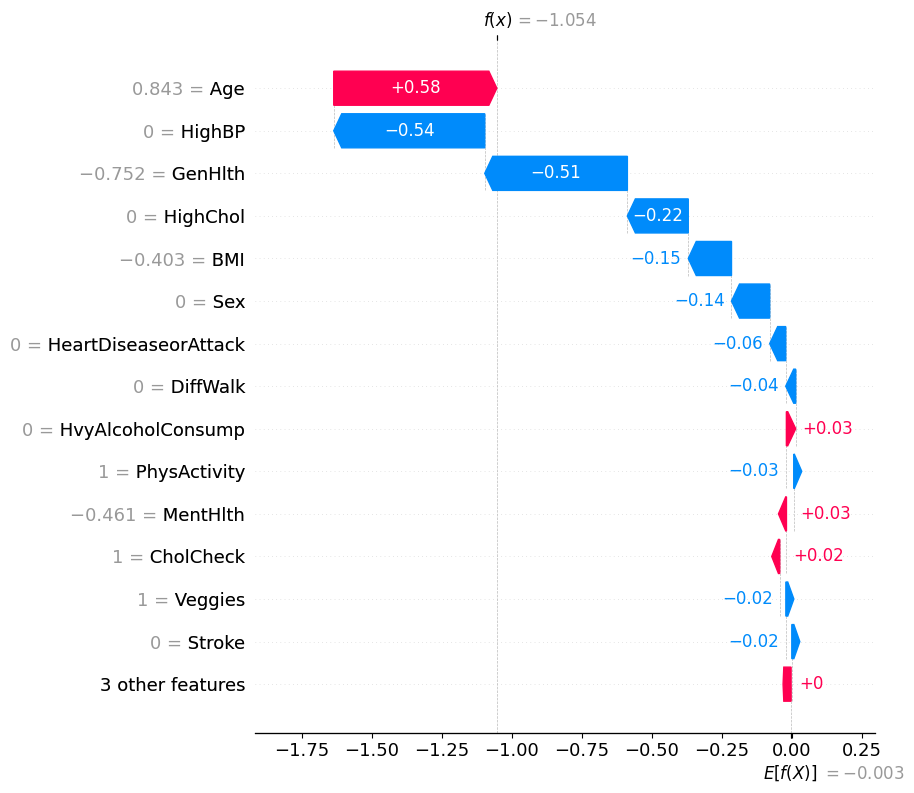

Paciente 9


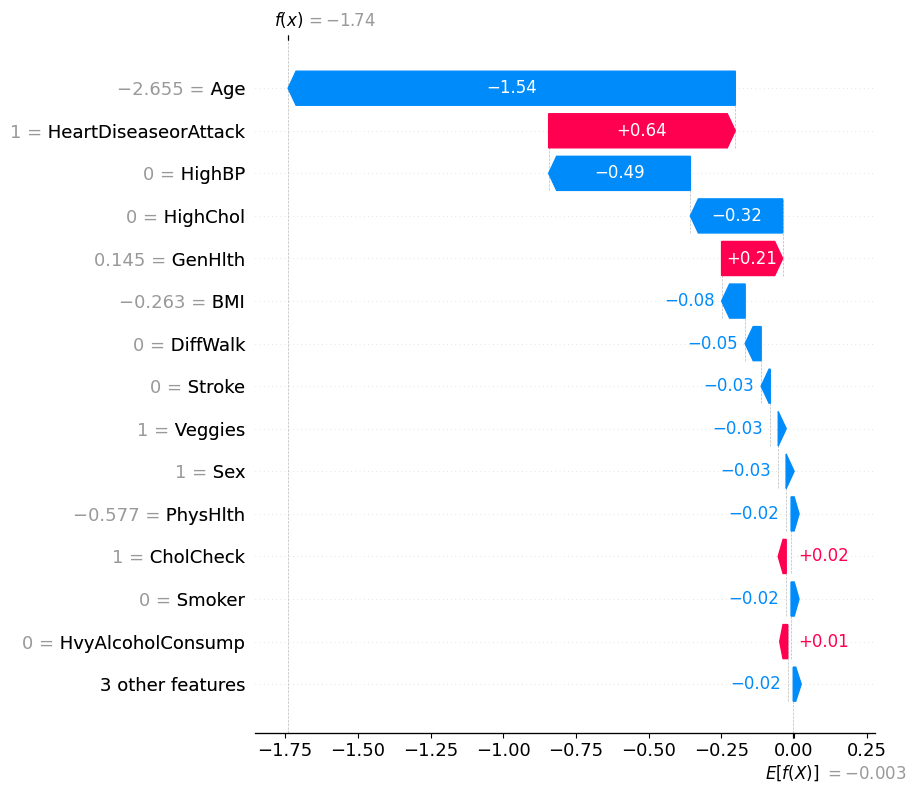

Paciente 150


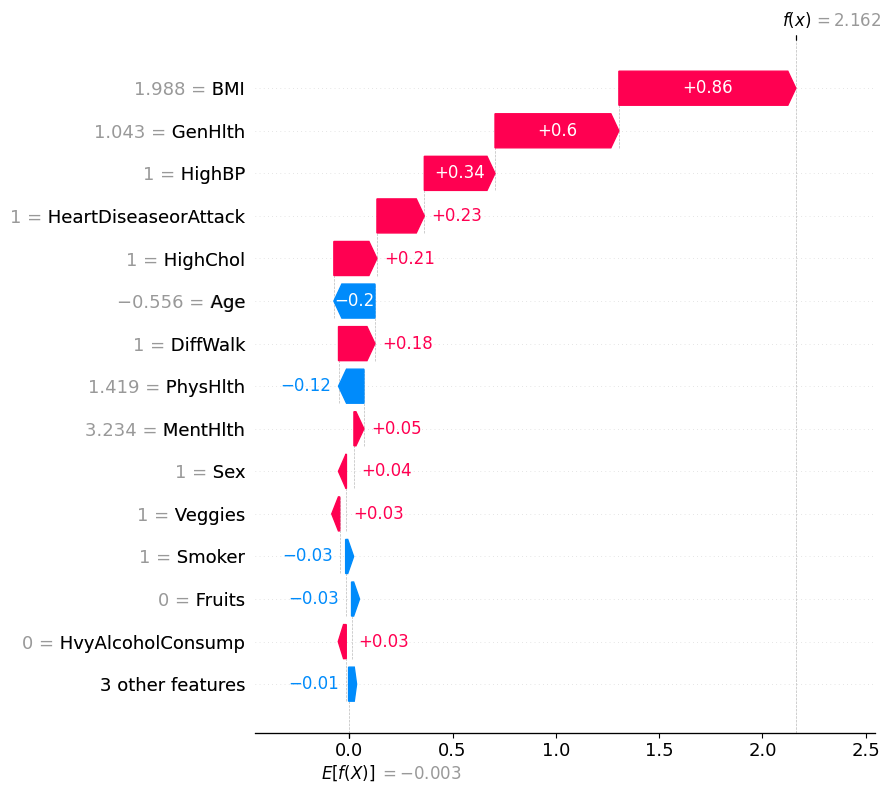

In [9]:
for i in [1, 9, 150]:
    print(f"Paciente {i}")
    exp = shap.Explanation(values=shap_values[i],base_values=explainer.expected_value,data=Xt.iloc[i].values,feature_names=Xt.columns)
    shap.waterfall_plot(exp, max_display=15)

5.2.2

Entre las que más contribuyen positivamente se encuentran:
BMI alto, GenHlth baja (peor salud general),HighBP = 1 (presión alta),
HighChol = 1 (colesterol alto),y edad elevada. Todo esto, calza directamente con lo visto en las permutation importances.

Por otro lado, valores bajos de estas mismas variables tienen un efecto negativo en la predicción, reduciendo la probabilidad de diabetes para el modelo.

En los tres pacientes analizados se repite un patrón claro: las variables relacionadas con salud metabólica y cardiovascular, las variables antes mencionadas son las que más peso tienen en la predicción, tanto positiva como negativamente.

Además, las variables de estilo de vida muestran contribuciones menores o cercanas a cero.
Por lo que el modelo se basa directamente en las variables asociadas a salud, lo cual hace sentido lógico..

Los resultados locales muestran cómo cada variable influye en casos concretos, pero no necesariamente representan el comportamiento global del modelo.

Sin embargo, al comparar estos resultados con los obtenidos en los resultados globales de SHAP y Permutation Importance, se observa una consistencia en las variables dominantes, lo que sugiere que los mismos factores (salud general, IMC, edad y presión alta) son los más relevantes de forma general.

Aun así, la magnitud y dirección exacta del efecto varía claramente entre individuos, por lo que estas conclusiones deben interpretarse sólo como tendencias.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

/tmp/ipython-input-2512356165.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, Xt, plot_type="bar", show=True)


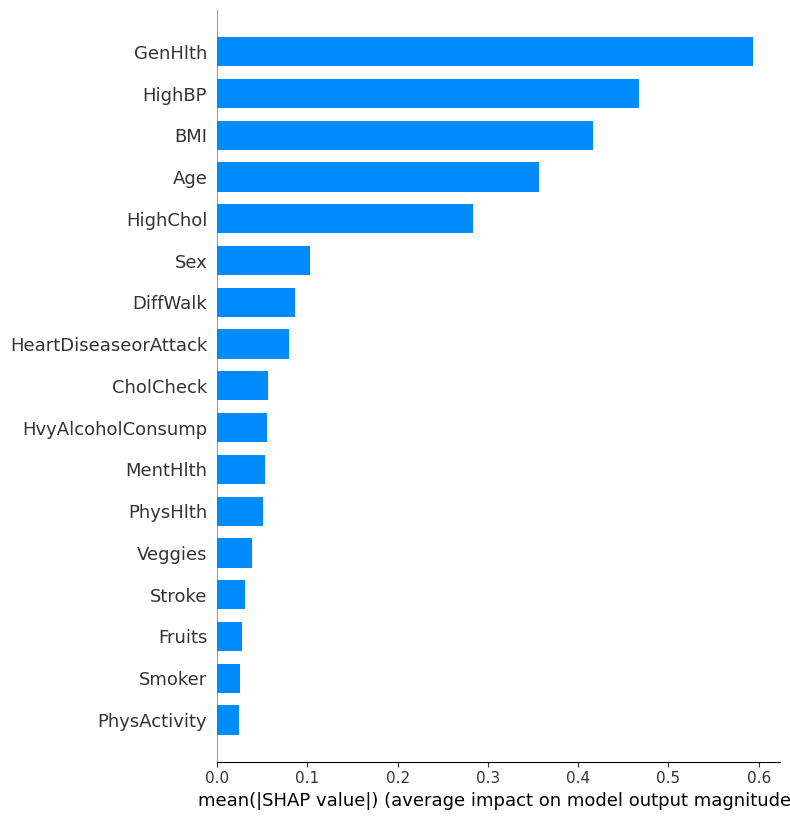

In [10]:
shap.summary_plot(shap_values, Xt, plot_type="bar", show=True)

A nivel de instancia, los plots mostraban cómo cada variable influía en pacientes específicos, indicando la dirección del efecto y su magnitud.

En cambio, el gráfico global no muestra el signo, solo la magnitud promedio del impacto en el conjunto de todos los pacientes.

Por eso, el análisis global permite identificar qué variables son más importantes en general para que el modelo decida, no así, el porque se está tomando una decisión particular para cada individuo.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

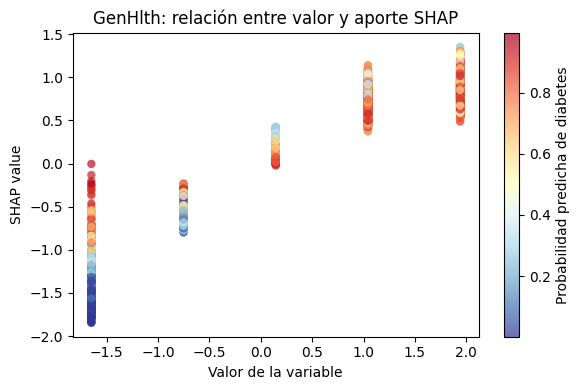

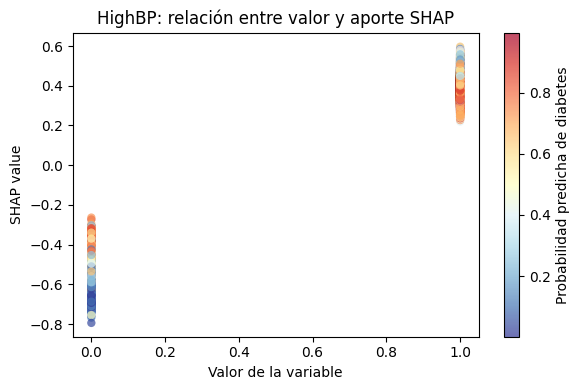

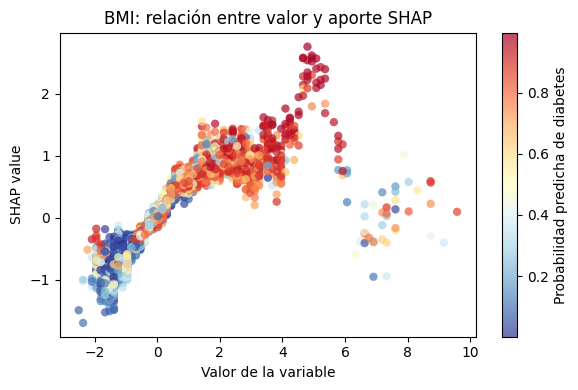

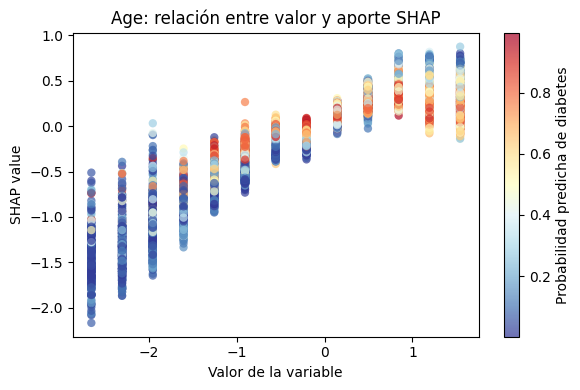

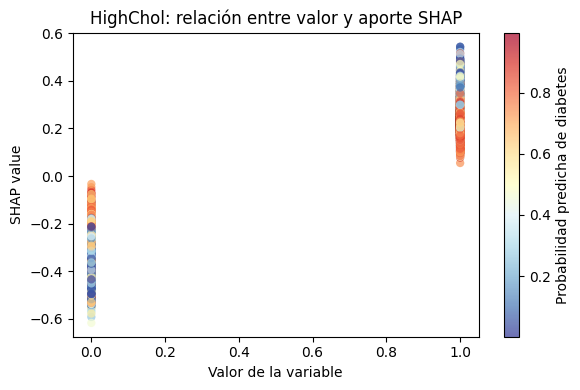

In [11]:
import matplotlib.pyplot as plt
import numpy as np

probs = pipe.predict_proba(X_test)[:, 1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)

for f in Xt.columns[np.argsort(mean_abs_shap)[-5:]][::-1]:
    plt.figure(figsize=(6, 4))
    sc = plt.scatter(Xt[f],shap_values[:, Xt.columns.get_loc(f)],c=probs,cmap="RdYlBu_r",alpha=0.7,edgecolors='none')
    plt.colorbar(sc, label="Probabilidad predicha de diabetes")
    plt.title(f"{f}: relación entre valor y aporte SHAP")
    plt.xlabel("Valor de la variable")
    plt.ylabel("SHAP value")
    plt.tight_layout()
    plt.show()


En las cinco variables más influyentes se observa una relación positiva entre el valor de la variable y su SHAP value, lo que indica que valores altos de estas características incrementan la probabilidad de diabetes.

En conjunto, los gráficos muestran que las variables con mayor impacto global también presentan patrones claros y consistentes a nivel individual, donde observando los colores, en general y de manera sostenida,los puntos con mayor probabilidad predicha (rojos) se concentran en las zonas de mayores valores de las features, donde además, los SHAP values de estas suben, mostrando que son más importantes para el modelo mientras más disparadas se encuentran.


### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

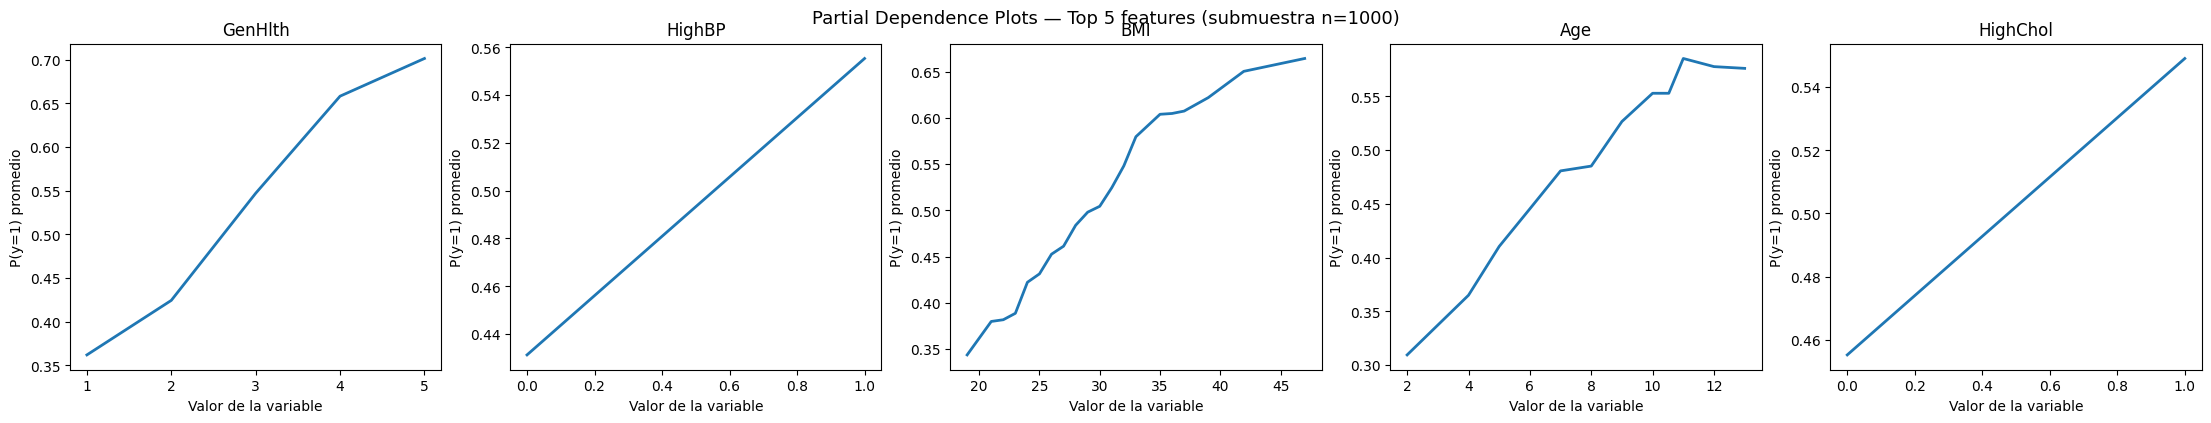

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mean_abs_shap = np.abs(shap_values).mean(axis=0)

n = 1000
idx = np.random.choice(len(X_test), size=n, replace=False)
X_sub = X_test.iloc[idx].copy()

def pdp_for_feature(pipe, X_base, col, n_grid=30):
    x = X_base[col]

    if x.nunique() <= 2:
        grid = np.sort(x.unique())
    else:
        grid = np.quantile(x, np.linspace(0.02, 0.98, n_grid))
        grid = np.unique(np.round(grid, 6))
    y_mean = []
    for v in grid:
        X_tmp = X_base.copy()
        X_tmp[col] = v
        p = pipe.predict_proba(X_tmp)[:, 1]
        y_mean.append(p.mean())
    return grid, np.array(y_mean)

fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)
for ax, f in zip(axes, Xt.columns[np.argsort(mean_abs_shap)[-5:]][::-1] ):
    xs, ys = pdp_for_feature(pipe, X_sub, f, n_grid=30)
    ax.plot(xs, ys, lw=2)
    ax.set_title(f)
    ax.set_xlabel("Valor de la variable")
    ax.set_ylabel("P(y=1) promedio")
plt.suptitle("Partial Dependence Plots — Top 5 features (submuestra n=1000)", y=1.02, fontsize=13)
plt.show()



Se observa que para las 5 features más importantes, la probabilidad de que Y=1 aumenta fuertmente a medida que aumenta el valor de la variable, siendo así proporcional para las 5 y siendo consistente con lo visto anteriormente en los Scatter Plot.

Estas relaciones son representativas pero no totalmente generalizables.
El PDP se está calculando solo sobre una submuestra y promedia los efectos de cada variable, por lo que muestra una tendencia global, sin embargo, asume independencia condicional entre las features, pudiendo ocultar relaciones entre variables o correlaciones.

Las tendencias observadas son coherentes con los resultados obtenidos mediante los SHAP values, capturando correctamente el funcionamiento general del modelo.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [25]:
import numpy as np
import pandas as pd
from alibi.explainers import AnchorTabular

preprocessor = pipe.named_steps['prep']
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

def predict_fn(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train_prep.columns)
    return pipe.named_steps['clf'].predict(X)

explainer = AnchorTabular(
    predictor=predict_fn,
    feature_names=list(X_train_prep.columns),
    categorical_names={}
)

explainer.fit(X_train_prep.values, disc_perc=[25, 50, 75])

explanations = {}
rules_summary = []

for idx in [1000, 3001, 5751]:
    instance = X_test_prep.iloc[idx].values.reshape(1, -1)
    prediction = predict_fn(instance)[0]
    proba = pipe.predict_proba(X_test.iloc[[idx]])[0]

    explanation = explainer.explain(instance, threshold=0.95, beam_size=4, coverage_samples=10000)

    explanations[idx] = explanation

    rules_summary.append({'Observación': idx,'Predicción': 'Diabetes' if prediction == 1 else 'No Diabetes','Prob_Diabetes': proba[1],'Reglas': ' AND '.join(explanation.anchor),'Precisión': explanation.precision,'Cobertura': explanation.coverage})


rules_df = pd.DataFrame(rules_summary)

cobertura_promedio = rules_df['Cobertura'].mean()
precision_promedio = rules_df['Precisión'].mean()


print(f"Población explicable (cobertura promedio): {cobertura_promedio:.3f} ({cobertura_promedio*100:.1f}%)")
print(f"Precisión promedio de las reglas: {precision_promedio:.3f}")

rules_df.head(15)

Población explicable (cobertura promedio): 0.207 (20.7%)
Precisión promedio de las reglas: 0.961


,Observación,Predicción,Prob_Diabetes,Reglas,Precisión,Cobertura
0,1000,No Diabetes,0.337135,GenHlth <= -0.75 AND BMI <= -0.68 AND DiffWalk...,0.959322,0.1481
1,3001,Diabetes,0.631445,BMI > -0.12 AND HighBP > 0.00 AND Age > -0.56,0.962222,0.2383
2,5751,No Diabetes,0.371020,HighBP <= 0.00 AND GenHlth <= -0.75 AND HeartD...,0.962742,0.2331


Con las reglas propuestas es posible explicar aproximadamente al 20.7% de la población. Las reglas poseen así una precisión promedio de 96.1%, sólo para este porcentaje, significativamente superior a la precisión general del modelo. Las tres reglas generadas tienen total coherencia médica: las observaciones 1000 y 5751 (sin diabetes) presentan perfiles saludables con buena salud general, BMI bajo, ausencia de hipertensión y sin complicaciones cardiovasculares; mientras que la observación 3001 (con diabetes) muestra el patrón que se ha visto durante todo el laboratorio, mayor edad y Peso e hipertensión son factores muy importantes para predecir diabetes.

El impacto sobre el conjunto de datos es que las reglas complementan al modelo, identificando asi subgrupos donde el modelo puede tener  una precisión particularmente alta, donde pueden explicar decisiones individuales con 3-4 condiciones simples y clínicamente muy interpretables.

Si se evalúan respecto de la totalidad de los datos, las reglas explican correctamente cerca del 19.8 % (0.96x 0.207) de las observaciones, ya que el resto del conjunto no se encuentra cubierto por las condiciones definidas.



# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

Entre los distintos métodos aplicados, los que entregan mejores conclusiones para la tarea de clasificación de diabetes son los basados en SHAP.

SHAP permite cuantificar con precisión el impacto y dirección de cada variable tanto a nivel global como individual, siendo altamente interpretables y entendiendo como funciona el modelo por debajo para clasificar diabetes, mostrando consigo patrones clínicos consistentes en la predicción.

 Permutation Importance también aporta una buena estimación de importancia global, pero sin mostrar interacciones ni direcciones de efecto, por lo que  se concluye que SHAP ahonda un poco más y aporta más a las conclusiones locales.

En el contexto del problema, los métodos agnósticos locales (como SHAP local o anchors) resultan más útiles, ya que permiten justificar predicciones caso a caso, comunicando con claridad las razones específicas de cada decisión.

Los métodos globalesc omplementan este análisis ofreciendo una visión general del comportamiento del modelo, pero no son capaces de mostrar "cuanto mueve la aguja" cada feature para cada caso específico.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>